# 🤖 Module 3: Feature Engineering & ML Model Training
## Loan Risk Analysis — Applicant Credit Assessment

**Pipeline:**
1. Feature Engineering & Preprocessing
2. Encoding Categorical Variables
3. Model Training (Logistic Regression, Random Forest, XGBoost)
4. Evaluation & Model Comparison
5. Feature Importance Analysis
6. Save Best Model for Inference


In [ ]:
# !pip install scikit-learn xgboost imbalanced-learn joblib matplotlib seaborn

In [1]:
import pandas as pd
import numpy as np
import os, joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, roc_auc_score)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

import matplotlib.pyplot as plt
import seaborn as sns

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print('⚠️  XGBoost not installed — will use GradientBoostingClassifier instead')

os.makedirs('models', exist_ok=True)
os.makedirs('outputs', exist_ok=True)
print('✅ Libraries loaded')

⚠️  XGBoost not installed — will use GradientBoostingClassifier instead
✅ Libraries loaded


## 3.1 Load Data

In [2]:
df = pd.read_csv('data/loan_risk_enriched.csv')
print(f'Loaded {df.shape[0]:,} rows, {df.shape[1]} columns')
print('Target distribution:')
print(df['risk_level'].value_counts())

Loaded 2,000 rows, 35 columns
Target distribution:
risk_level
low       771
medium    729
high      500
Name: count, dtype: int64


## 3.2 Feature Selection & Preprocessing

In [3]:
# Drop non-predictive identifier / leakage columns
DROP_COLS = ['applicant_id', 'full_name', 'application_date', 'processing_branch',
             'approval_status',    # downstream outcome — not available at decision time
             'interest_rate_pct',  # assigned post-assessment, could leak
             'application_month']  # redundant with application_date

TARGET = 'risk_level'

df_model = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

# Encode target
le_target = LabelEncoder()
df_model['risk_encoded'] = le_target.fit_transform(df_model[TARGET])
joblib.dump(le_target, 'models/label_encoder.pkl')
print(f'Classes: {le_target.classes_}  →  {list(range(len(le_target.classes_)))}')

X = df_model.drop(columns=[TARGET, 'risk_encoded'])
y = df_model['risk_encoded']

# Identify column types
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols   = X.select_dtypes(include=[np.number]).columns.tolist()

print(f'\nFeatures: {X.shape[1]} total')
print(f'  Numerical   ({len(numerical_cols)}): {numerical_cols}')
print(f'  Categorical ({len(categorical_cols)}): {categorical_cols}')

Classes: ['high' 'low' 'medium']  →  [0, 1, 2]

Features: 27 total
  Numerical   (16): ['age', 'years_employed', 'annual_income_inr', 'monthly_expenses_inr', 'loan_amount_inr', 'loan_tenure_months', 'credit_score', 'debt_to_income_ratio', 'existing_loans', 'previous_defaults', 'collateral_value_inr', 'bank_account_age_years', 'num_credit_inquiries_6m', 'savings_balance_inr', 'income_to_loan_ratio', 'savings_months_cover']
  Categorical (11): ['gender', 'marital_status', 'education_level', 'city', 'state', 'employment_type', 'loan_purpose', 'property_ownership', 'has_collateral', 'co_applicant', 'age_group']


## 3.3 Build Preprocessing Pipeline & Split Data

In [4]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}')
print(f'   Train class balance: {dict(zip(le_target.classes_, np.bincount(y_train)))}')

✅ Train size: 1,600 | Test size: 400
   Train class balance: {'high': np.int64(400), 'low': np.int64(617), 'medium': np.int64(583)}


## 3.4 Define & Train Models

In [5]:
boost_model = (XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                              use_label_encoder=False, eval_metric='mlogloss',
                              random_state=42, n_jobs=-1)
               if XGB_AVAILABLE else
               GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                          learning_rate=0.1, random_state=42))
boost_name = 'XGBoost' if XGB_AVAILABLE else 'Gradient Boosting'

MODELS = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                                               multi_class='multinomial', random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, max_depth=15,
                                                   n_jobs=-1, random_state=42),
    boost_name           : boost_model,
}

results  = []
trained  = {}

for name, model in MODELS.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test) if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')
    auc  = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted') if y_proba is not None else np.nan

    results.append({'Model': name, 'Accuracy': round(acc, 4),
                    'F1 (weighted)': round(f1, 4), 'ROC-AUC': round(auc, 4)})
    trained[name] = (pipe, y_pred)
    print(f'{name:25s} | Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}')

results_df = pd.DataFrame(results).sort_values('F1 (weighted)', ascending=False)
print('\n', results_df.to_string(index=False))

Logistic Regression       | Acc: 0.9650 | F1: 0.9650 | AUC: 0.9977
Random Forest             | Acc: 0.9800 | F1: 0.9799 | AUC: 0.9993
Gradient Boosting         | Acc: 0.9775 | F1: 0.9775 | AUC: 0.9994

               Model  Accuracy  F1 (weighted)  ROC-AUC
      Random Forest    0.9800         0.9799   0.9993
  Gradient Boosting    0.9775         0.9775   0.9994
Logistic Regression    0.9650         0.9650   0.9977


## 3.5 Best Model — Detailed Evaluation

In [6]:
best_name = results_df.iloc[0]['Model']
best_pipe, best_preds = trained[best_name]
print(f'🏆 Best Model: {best_name}\n')
print(classification_report(y_test, best_preds, target_names=le_target.classes_))

🏆 Best Model: Random Forest

              precision    recall  f1-score   support

        high       0.98      0.96      0.97       100
         low       0.99      1.00      0.99       154
      medium       0.97      0.97      0.97       146

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



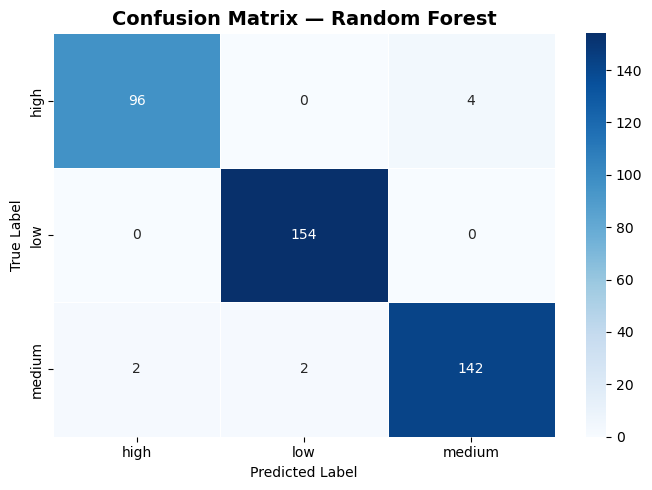

✅ Saved → outputs/confusion_matrix.png


In [7]:
# Confusion matrix
cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_, linewidths=0.5)
plt.title(f'Confusion Matrix — {best_name}', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → outputs/confusion_matrix.png')

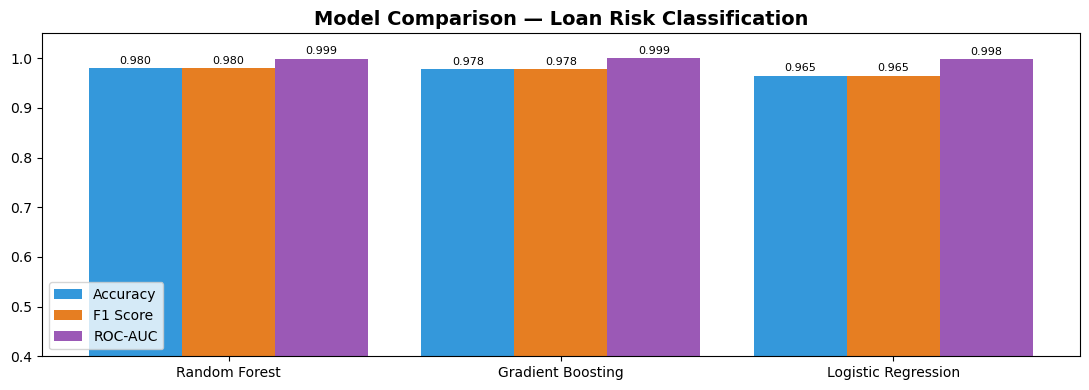

✅ Saved → outputs/model_comparison.png


In [8]:
# Model comparison chart
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(results_df))
w = 0.28
bars_acc = ax.bar(x - w, results_df['Accuracy'],       w, label='Accuracy',     color='#3498db')
bars_f1  = ax.bar(x,     results_df['F1 (weighted)'],  w, label='F1 Score',     color='#e67e22')
bars_auc = ax.bar(x + w, results_df['ROC-AUC'],        w, label='ROC-AUC',      color='#9b59b6')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'])
ax.set_ylim(0.4, 1.05)
ax.set_title('Model Comparison — Loan Risk Classification', fontsize=14, fontweight='bold')
ax.legend()
for bar in list(bars_acc) + list(bars_f1) + list(bars_auc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → outputs/model_comparison.png')

## 3.6 Cross-Validation

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_pipe, X_train, y_train,
                             cv=cv, scoring='f1_weighted', n_jobs=-1)
print(f'5-Fold CV F1 Scores : {cv_scores.round(4)}')
print(f'Mean ± Std          : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

5-Fold CV F1 Scores : [0.9781 0.9875 0.9906 0.9969 0.9781]
Mean ± Std          : 0.9862 ± 0.0073


## 3.7 Feature Importance

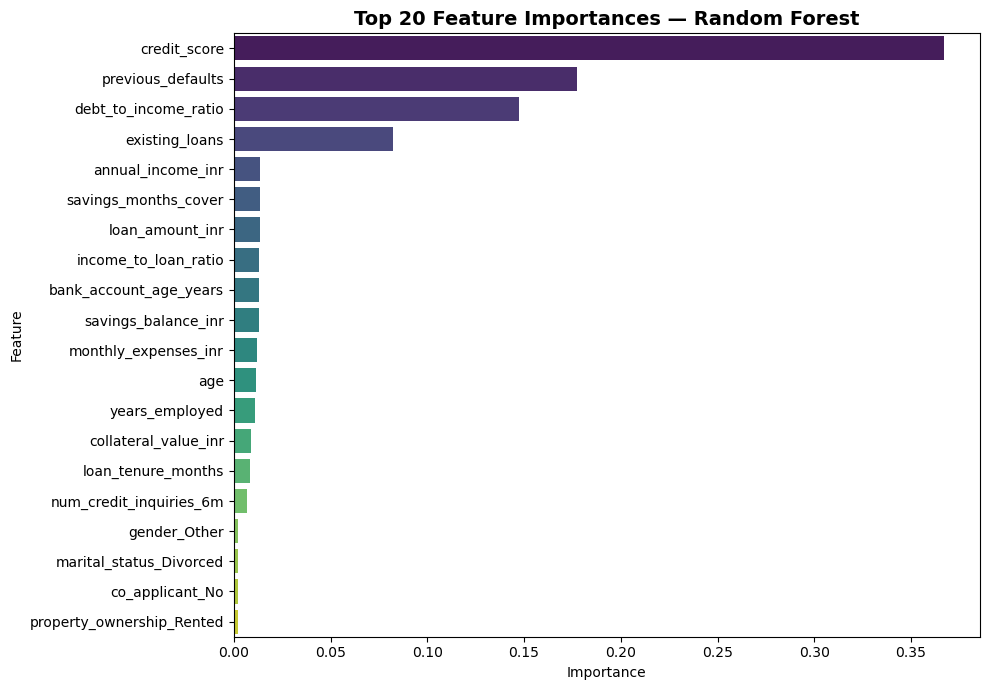

✅ Saved → outputs/feature_importance.png

Top 10 Features:
               Feature  Importance
          credit_score    0.367250
     previous_defaults    0.177123
  debt_to_income_ratio    0.147274
        existing_loans    0.082276
     annual_income_inr    0.013659
  savings_months_cover    0.013620
       loan_amount_inr    0.013481
  income_to_loan_ratio    0.013243
bank_account_age_years    0.013121
   savings_balance_inr    0.012972


In [10]:
# Extract feature names after OneHotEncoding
ohe_features = best_pipe.named_steps['preprocessor']\
    .named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
all_features = numerical_cols + ohe_features

clf = best_pipe.named_steps['classifier']
if hasattr(clf, 'feature_importances_'):
    importances = clf.feature_importances_
elif hasattr(clf, 'coef_'):
    importances = np.abs(clf.coef_).mean(axis=0)
else:
    importances = None

if importances is not None:
    feat_df = pd.DataFrame({'Feature': all_features[:len(importances)],
                            'Importance': importances})\
                .sort_values('Importance', ascending=False).head(20)

    plt.figure(figsize=(10, 7))
    sns.barplot(data=feat_df, y='Feature', x='Importance', palette='viridis')
    plt.title(f'Top 20 Feature Importances — {best_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('outputs/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved → outputs/feature_importance.png')
    print('\nTop 10 Features:')
    print(feat_df.head(10).to_string(index=False))
else:
    print('Feature importances not available for this model type.')

## 3.8 Save Best Model

In [11]:
joblib.dump(best_pipe, 'models/best_model.pkl')
joblib.dump(results_df, 'models/results_summary.pkl')

print(f'✅ Best model ({best_name}) saved → models/best_model.pkl')
print(f'✅ Label encoder saved           → models/label_encoder.pkl')
print(f'✅ Results summary saved         → models/results_summary.pkl')

✅ Best model (Random Forest) saved → models/best_model.pkl
✅ Label encoder saved           → models/label_encoder.pkl
✅ Results summary saved         → models/results_summary.pkl


## 3.9 Inference — Predict Risk for New Applicants

In [12]:
def predict_risk(applicants: list[dict]) -> pd.DataFrame:
    """Predict loan risk level for a list of applicant dicts.

    Each dict must contain the same feature columns used during training
    (excluding applicant_id, full_name, approval_status, etc.).
    """
    _pipe = joblib.load('models/best_model.pkl')
    _le   = joblib.load('models/label_encoder.pkl')

    df_in = pd.DataFrame(applicants)
    preds  = _pipe.predict(df_in)
    probas = _pipe.predict_proba(df_in)

    out = df_in[['age', 'annual_income_inr', 'credit_score', 'debt_to_income_ratio']].copy()
    out['predicted_risk']     = _le.inverse_transform(preds)
    for i, cls in enumerate(_le.classes_):
        out[f'prob_{cls}'] = probas[:, i].round(3)
    return out


# Sample applicants
test_applicants = [
    {
        'age': 35, 'gender': 'Male', 'marital_status': 'Married',
        'education_level': "Bachelor's", 'city': 'Mumbai', 'state': 'Maharashtra',
        'employment_type': 'Salaried', 'years_employed': 8.0,
        'annual_income_inr': 1200000, 'monthly_expenses_inr': 35000,
        'loan_purpose': 'Home Loan', 'loan_amount_inr': 4500000,
        'loan_tenure_months': 240, 'credit_score': 780,
        'debt_to_income_ratio': 0.22, 'existing_loans': 1, 'previous_defaults': 0,
        'property_ownership': 'Rented', 'has_collateral': 'Yes',
        'collateral_value_inr': 5000000, 'co_applicant': 'No',
        'bank_account_age_years': 10.0, 'num_credit_inquiries_6m': 1,
        'savings_balance_inr': 800000, 'income_to_loan_ratio': 0.267,
        'savings_months_cover': 22.9, 'age_group': '31–40'
    },
    {
        'age': 55, 'gender': 'Female', 'marital_status': 'Single',
        'education_level': 'High School', 'city': 'Jaipur', 'state': 'Rajasthan',
        'employment_type': 'Unemployed', 'years_employed': 0.0,
        'annual_income_inr': 180000, 'monthly_expenses_inr': 18000,
        'loan_purpose': 'Personal Loan', 'loan_amount_inr': 500000,
        'loan_tenure_months': 36, 'credit_score': 590,
        'debt_to_income_ratio': 0.68, 'existing_loans': 3, 'previous_defaults': 2,
        'property_ownership': 'Rented', 'has_collateral': 'No',
        'collateral_value_inr': 0, 'co_applicant': 'No',
        'bank_account_age_years': 2.0, 'num_credit_inquiries_6m': 7,
        'savings_balance_inr': 12000, 'income_to_loan_ratio': 0.36,
        'savings_months_cover': 0.67, 'age_group': '51–64'
    },
]

result = predict_risk(test_applicants)
print('=== Risk Prediction Results ===')
print(result.to_string(index=False))

=== Risk Prediction Results ===
 age  annual_income_inr  credit_score  debt_to_income_ratio predicted_risk  prob_high  prob_low  prob_medium
  35            1200000           780                  0.22            low      0.017     0.905        0.077
  55             180000           590                  0.68           high      0.892     0.000        0.108
